In [1]:
%pwd

'/Users/nicholasstanfield/Desktop/flight-delay/notebooks'

In [55]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [26]:
model = joblib.load("../models/xgboost_v1.joblib")

In [27]:
df = pd.read_csv("../data/processed/flight_weather_data_2025.csv")
df.shape

(359999, 32)

In [28]:
X = df.drop("DELAY", axis=1)
y = df["DELAY"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

In [29]:
preprocessing = model.steps[0][1]

In [12]:
xgb = model.steps[1][1]

In [63]:
def clean_feature_names(feature_names):

    features = list(feature_names)

    cleaned_features = []

    for feature in features:
        feature = feature.replace("num__", "")
        feature = feature.replace("cat__","")
        feature = feature.title()
        feature = feature.replace("_", " ")
        feature = feature.replace("Dest", "Destination")
        feature = feature.replace("Arr", "Arrival Airport")
        feature = feature.replace("Dep", "Departure")


        if feature == "Crs Elapsed Time":
            feature = "Expected Flight Time"
        elif feature == "Distance":
            feature = "Flight Distance"
        elif feature == 'Departure Snow Departureth':
            feature = 'Departure Snow Depth'
        elif feature == 'Arrival Snow Departureth':
            feature = 'Arrival Snow Depth'

        cleaned_features.append(feature)


    return np.array(cleaned_features)

In [64]:
import matplotlib.pyplot as plt

feature_names = preprocessing.get_feature_names_out()
feature_names = clean_feature_names(feature_names)
feature_importances = xgb.feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "feature_importance":feature_importances})

<Axes: ylabel='feature'>

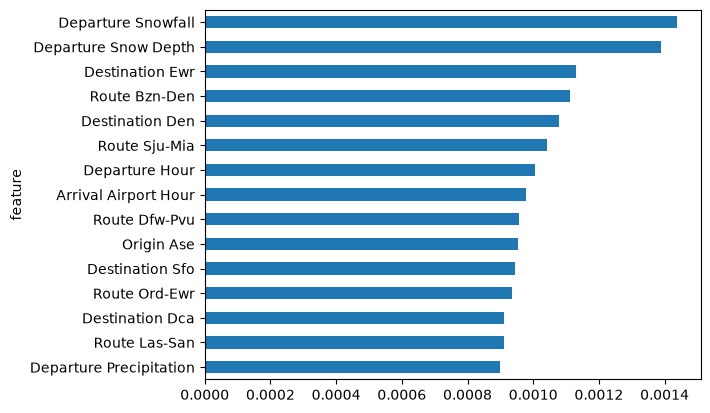

In [67]:
importance_df.sort_values("feature_importance", ascending=False).head(15).sort_values('feature_importance').plot(x='feature',
                                                                               y='feature_importance',
                                                                               kind='barh',
                                                                               legend=False)

## Error Analysis

In [69]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["delay_probability"] = y_prob

In [70]:
error_df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,AIRLINE,ROUTE,ORIGIN_LATITUDE,...,ARR_SNOW_DEPTH,ARR_VISIBILITY,ARR_SURFACE_PRESSURE,ARR_WIND_SPEED,ARR_WIND_GUSTS,DEP_HOUR,ARR_HOUR,actual,predicted,delay_probability
117431,4,7,1,LAS,RNO,85.0,345.0,Southwest Airlines Co.,LAS-RNO,36.083361,...,0.0,32000.0,867.0,2.2,16.2,21,23,0,0,0.241737
302441,11,6,4,DFW,CVG,135.0,812.0,Frontier Airlines Inc.,DFW-CVG,32.896801,...,0.0,66200.0,989.6,8.9,10.8,13,16,1,0,0.227061
272050,10,18,6,MCO,IAH,157.0,854.0,United Air Lines Inc.,MCO-IAH,28.429399,...,0.0,13600.0,1007.1,2.5,9.4,7,8,0,0,0.063653
249258,9,12,5,SAN,HNL,370.0,2614.0,Hawaiian Airlines Inc.,SAN-HNL,32.733601,...,0.0,24140.0,1018.1,18.6,47.2,9,12,1,0,0.114162
312531,11,5,3,CMH,BOS,125.0,640.0,Republic Airline,CMH-BOS,39.998001,...,0.0,21700.0,1000.7,15.7,55.1,17,19,0,0,0.302964


In [71]:
def classify_prediction(row):
    
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    
    elif row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    
    else:
        return "False Negative"


error_df["prediction_type"] = error_df.apply(
    classify_prediction,
    axis=1
)

In [73]:
error_df["prediction_type"].value_counts(normalize=False)

prediction_type
True Negative     53274
False Negative    12249
True Positive      3757
False Positive     2720
Name: count, dtype: int64

* The model is still quite poor at successfully predicting a delay, in particular it missed 12,249 flights which should have been predicted as delayed. Interestingly, there is also a large number of false positives, i.e. predicted as delayed but not actually delayed showing the model has poor precision and recall

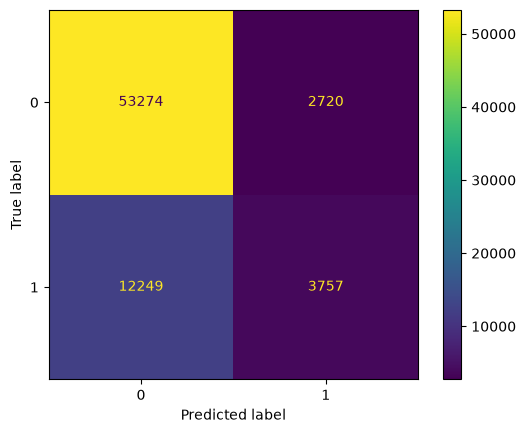

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [78]:
false_positives = (
    error_df[
        error_df["prediction_type"] == "False Positive"
    ]
    .sort_values("delay_probability", ascending=False)
)

false_positives.head(5)

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,AIRLINE,ROUTE,ORIGIN_LATITUDE,...,ARR_SURFACE_PRESSURE,ARR_WIND_SPEED,ARR_WIND_GUSTS,DEP_HOUR,ARR_HOUR,actual,predicted,delay_probability,prediction_type,is_error
328869,11,29,6,CID,PHX,225.0,1252.0,SkyWest Airlines Inc.,CID-PHX,41.884701,...,977.3,7.0,15.8,7,10,0,1,0.977472,False Positive,True
6436,1,10,5,STL,LAS,230.0,1371.0,Southwest Airlines Co.,STL-LAS,38.748697,...,951.6,4.7,10.8,6,8,0,1,0.966408,False Positive,True
306828,11,30,7,ORD,PBI,192.0,1144.0,United Air Lines Inc.,ORD-PBI,41.978600,...,1017.3,18.3,27.0,10,15,0,1,0.960905,False Positive,True
55188,2,18,2,DEN,COS,51.0,73.0,United Air Lines Inc.,DEN-COS,39.860027,...,801.9,7.9,7.9,13,14,0,1,0.952086,False Positive,True
197344,7,14,1,DFW,ASE,150.0,701.0,SkyWest Airlines Inc.,DFW-ASE,32.896801,...,773.7,2.9,3.6,8,9,0,1,0.950179,False Positive,True


In [79]:
false_negatives = (
    error_df[
        error_df["prediction_type"] == "False Negative"
    ]
    .sort_values("delay_probability")
)

false_negatives.head(5)

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,AIRLINE,ROUTE,ORIGIN_LATITUDE,...,ARR_SURFACE_PRESSURE,ARR_WIND_SPEED,ARR_WIND_GUSTS,DEP_HOUR,ARR_HOUR,actual,predicted,delay_probability,prediction_type,is_error
89662,3,27,4,BUF,LGA,88.0,292.0,Republic Airline,BUF-LGA,42.940498,...,1022.6,10.3,24.1,6,7,1,0,0.002656,False Negative,True
89527,3,1,6,MAF,DAL,75.0,319.0,Southwest Airlines Co.,MAF-DAL,31.942499,...,998.6,3.1,3.2,6,7,1,0,0.006093,False Negative,True
27175,1,30,4,ORD,LGA,130.0,733.0,United Air Lines Inc.,ORD-LGA,41.978600,...,1023.7,18.5,39.6,6,9,1,0,0.006623,False Negative,True
102290,4,14,1,IND,LAS,245.0,1590.0,Southwest Airlines Co.,IND-LAS,39.717300,...,940.9,4.2,4.7,6,7,1,0,0.008200,False Negative,True
1779,1,27,1,MSN,ORD,71.0,108.0,SkyWest Airlines Inc.,MSN-ORD,43.139900,...,980.2,30.0,64.4,17,18,1,0,0.009369,False Negative,True


In [77]:
error_df["is_error"] = (
    error_df["actual"] != error_df["predicted"]
)

airline_errors = (
    error_df
    .groupby("AIRLINE")
    .agg(
        flights=("actual", "size"),
        error_rate=("is_error", "mean"),
        actual_delay_rate=("actual", "mean")
    )
    .sort_values("error_rate", ascending=False)
)

airline_errors

,flights,error_rate,actual_delay_rate
AIRLINE,,,
PSA Airlines Inc.,2531,0.266298,0.280522
Frontier Airlines Inc.,2094,0.259790,0.279847
JetBlue Airways,2350,0.252766,0.271064
Alaska Airlines Inc.,2540,0.239764,0.229528
American Airlines Inc.,9857,0.234453,0.255250
Allegiant Air,1348,0.224777,0.239614
Spirit Air Lines,1996,0.218437,0.220942
Envoy Air,3031,0.200924,0.209832
Republic Airline,3511,0.199089,0.227001
